<a href="https://colab.research.google.com/github/GodsentExplorer/circuit-dynamics-simulator/blob/main/python/circuit_dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ RC/RL/LC/RLC Circuit Dynamics Simulator
**Course:** Intermediate Electromagnetism  
**Tools:** Python, NumPy, SciPy, Matplotlib  

This notebook simulates and visualizes the transient and steady-state behavior
of RC, RL, LC, and RLC circuits by numerically solving their governing ODEs.

---
## Contents
1. RC Circuit — Charging & Discharging
2. RL Circuit — Current Buildup & Decay
3. LC Circuit — Undamped Oscillations
4. RLC Circuit — Damped Oscillations

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Notebook display settings
%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2,
})

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 1. RC Circuit — Charging & Discharging

**Governing ODE:**  
$$\frac{dV_C}{dt} = \frac{V_s - V_C}{RC}$$

- $V_C$ = voltage across capacitor  
- $V_s$ = source voltage  
- $\tau = RC$ = time constant

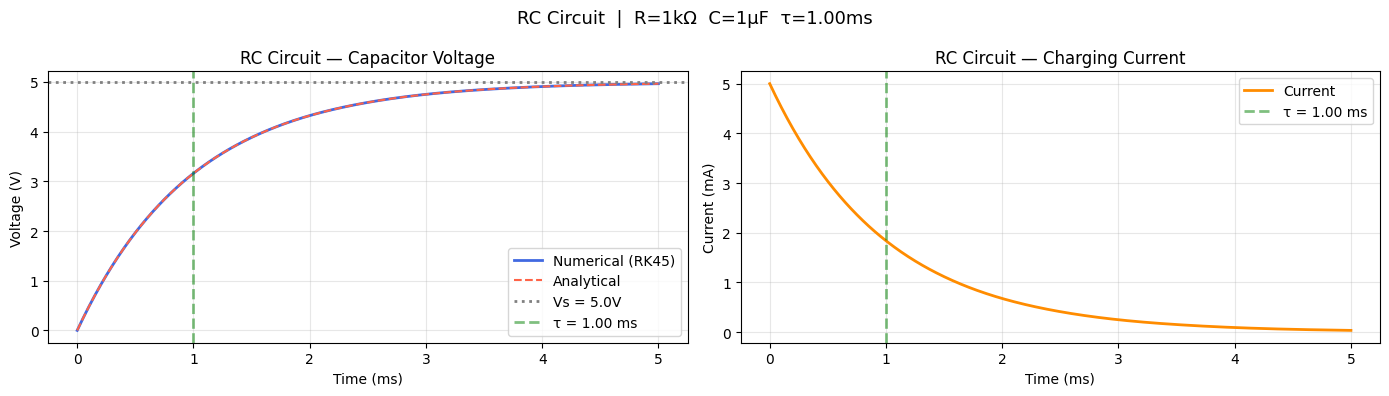

τ = 1.00 ms | At t=τ, Vc = 3.161V (should be ~3.160V)


In [2]:
# ── RC Circuit ────────────────────────────────────────────────────────────────

# Parameters
R = 1e3        # Resistance (Ohms) — 1 kΩ
C = 1e-6       # Capacitance (Farads) — 1 µF
Vs = 5.0       # Source voltage (V)
tau = R * C    # Time constant

t_span = (0, 5 * tau)
t_eval = np.linspace(*t_span, 500)

# ODE: dVc/dt = (Vs - Vc) / (R*C)
def rc_ode(t, y):
    Vc = y[0]
    dVc_dt = (Vs - Vc) / (R * C)
    return [dVc_dt]

# Solve numerically
sol = solve_ivp(rc_ode, t_span, y0=[0.0], t_eval=t_eval, method='RK45')
Vc_numerical = sol.y[0]

# Analytical solution
Vc_analytical = Vs * (1 - np.exp(-t_eval / tau))

# Current through resistor: I = (Vs - Vc) / R
I = (Vs - Vc_numerical) / R

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Voltage plot
ax1.plot(t_eval * 1e3, Vc_numerical, label='Numerical (RK45)', color='royalblue')
ax1.plot(t_eval * 1e3, Vc_analytical, '--', label='Analytical', color='tomato', linewidth=1.5)
ax1.axhline(Vs, color='gray', linestyle=':', label=f'Vs = {Vs}V')
ax1.axvline(tau * 1e3, color='green', linestyle='--', alpha=0.5, label=f'τ = {tau*1e3:.2f} ms')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('RC Circuit — Capacitor Voltage')
ax1.legend()

# Current plot
ax2.plot(t_eval * 1e3, I * 1e3, color='darkorange', label='Current')
ax2.axvline(tau * 1e3, color='green', linestyle='--', alpha=0.5, label=f'τ = {tau*1e3:.2f} ms')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Current (mA)')
ax2.set_title('RC Circuit — Charging Current')
ax2.legend()

plt.suptitle(f'RC Circuit  |  R={R/1e3:.0f}kΩ  C={C*1e6:.0f}µF  τ={tau*1e3:.2f}ms', fontsize=13)
plt.tight_layout()
plt.show()

print(f"τ = {tau*1e3:.2f} ms | At t=τ, Vc = {Vs*(1-np.exp(-1)):.3f}V (should be ~{0.632*Vs:.3f}V)")

## 2. RL Circuit — Current Buildup & Decay

**Governing ODE:**  
$$\frac{dI}{dt} = \frac{V_s - IR}{L}$$

- $I$ = current through inductor  
- $\tau = L/R$ = time constant  
- Inductor opposes changes in current

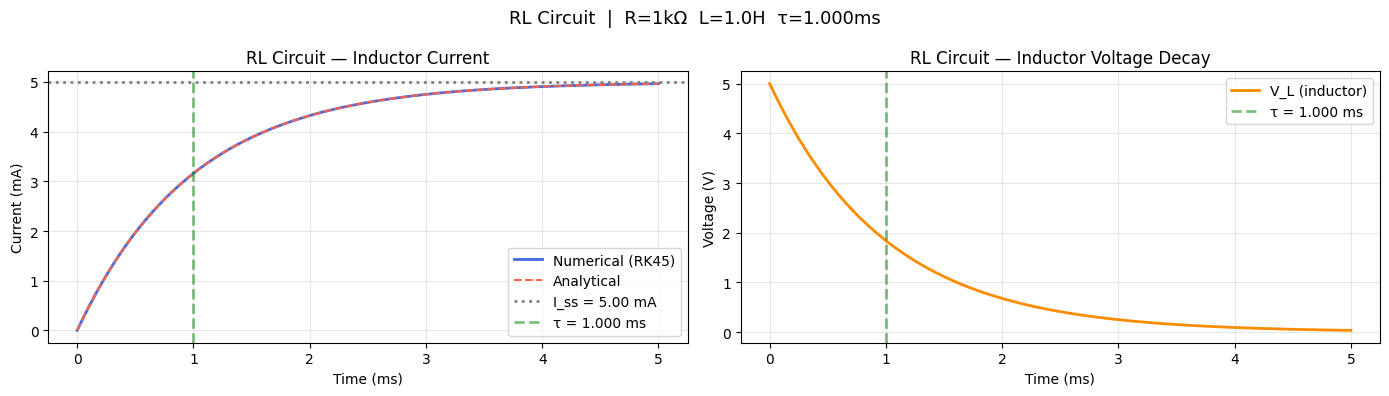

τ = 1.000 ms | I_ss = 5.00 mA | At t=τ, I = 3.161 mA


In [4]:
# ── RL Circuit ────────────────────────────────────────────────────────────────

# Parameters
R_rl = 1e3       # Resistance (Ohms) — 1 kΩ
L    = 1.0       # Inductance (Henrys) — 1 H
Vs_rl = 5.0      # Source voltage (V)
tau_rl = L / R_rl

t_span_rl = (0, 5 * tau_rl)
t_eval_rl = np.linspace(*t_span_rl, 500)

# ODE: dI/dt = (Vs - I*R) / L
def rl_ode(t, y):
    I = y[0]
    dI_dt = (Vs_rl - I * R_rl) / L
    return [dI_dt]

# Solve numerically
sol_rl = solve_ivp(rl_ode, t_span_rl, y0=[0.0], t_eval=t_eval_rl, method='RK45')
I_numerical = sol_rl.y[0]

# Analytical solution
I_analytical = (Vs_rl / R_rl) * (1 - np.exp(-t_eval_rl / tau_rl))
I_ss = Vs_rl / R_rl  # Steady-state current

# Voltage across inductor: V_L = L * dI/dt
VL = Vs_rl * np.exp(-t_eval_rl / tau_rl)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Current plot
ax1.plot(t_eval_rl * 1e3, I_numerical * 1e3, label='Numerical (RK45)', color='royalblue')
ax1.plot(t_eval_rl * 1e3, I_analytical * 1e3, '--', label='Analytical', color='tomato', linewidth=1.5)
ax1.axhline(I_ss * 1e3, color='gray', linestyle=':', label=f'I_ss = {I_ss*1e3:.2f} mA')
ax1.axvline(tau_rl * 1e3, color='green', linestyle='--', alpha=0.5, label=f'τ = {tau_rl*1e3:.3f} ms')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Current (mA)')
ax1.set_title('RL Circuit — Inductor Current')
ax1.legend()

# Inductor voltage plot
ax2.plot(t_eval_rl * 1e3, VL, color='darkorange', label='V_L (inductor)')
ax2.axvline(tau_rl * 1e3, color='green', linestyle='--', alpha=0.5, label=f'τ = {tau_rl*1e3:.3f} ms')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Voltage (V)')
ax2.set_title('RL Circuit — Inductor Voltage Decay')
ax2.legend()

plt.suptitle(f'RL Circuit  |  R={R_rl/1e3:.0f}kΩ  L={L:.1f}H  τ={tau_rl*1e3:.3f}ms', fontsize=13)
plt.tight_layout()
plt.show()

print(f"τ = {tau_rl*1e3:.3f} ms | I_ss = {I_ss*1e3:.2f} mA | At t=τ, I = {(I_ss*(1-np.exp(-1)))*1e3:.3f} mA")

## 3. LC Circuit — Undamped Oscillations

**Governing ODE (2nd order):**  
$$\frac{d^2V_C}{dt^2} + \frac{1}{LC}V_C = 0$$

Rewritten as a system:  
$$\frac{dV_C}{dt} = \frac{I}{C}, \qquad \frac{dI}{dt} = -\frac{V_C}{L}$$

- $\omega_0 = 1/\sqrt{LC}$ = natural frequency  
- No energy dissipation → perpetual oscillation  
- Phase portrait is a perfect ellipse

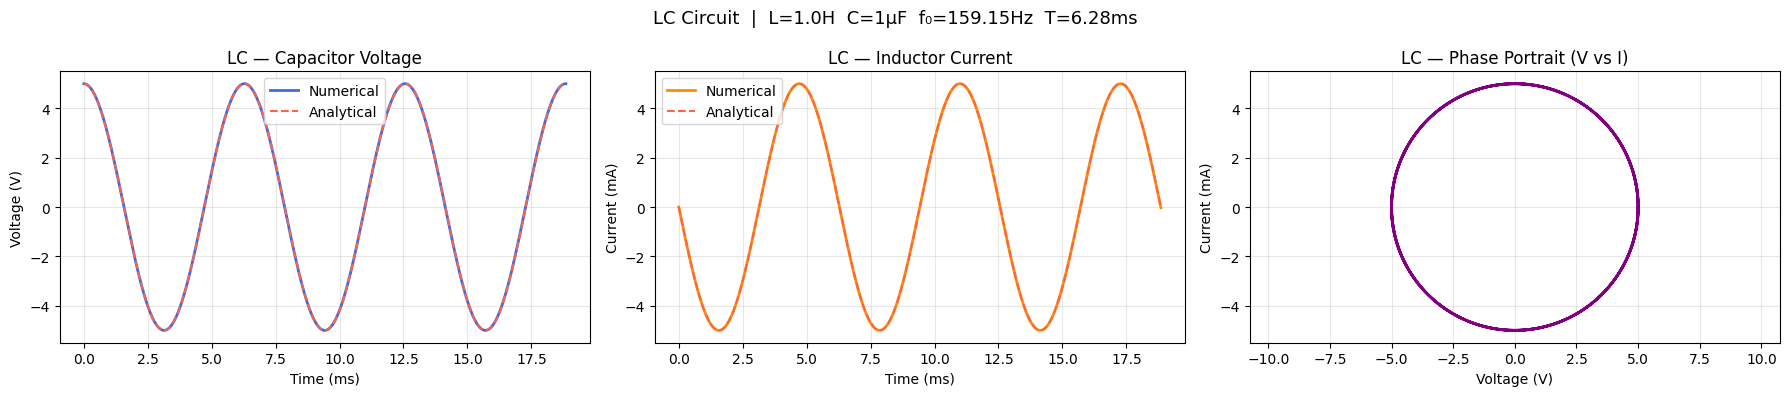

ω₀ = 1000.00 rad/s | f₀ = 159.15 Hz | T = 6.28 ms


In [5]:
# ── LC Circuit ────────────────────────────────────────────────────────────────

# Parameters
L_lc = 1.0       # Inductance (H)
C_lc = 1e-6      # Capacitance (F)
omega0 = 1 / np.sqrt(L_lc * C_lc)   # Natural frequency (rad/s)
f0 = omega0 / (2 * np.pi)            # Natural frequency (Hz)
T  = 1 / f0                          # Period (s)

# Initial conditions: Vc0 = 5V, I0 = 0A (charged capacitor, no current)
Vc0, I0 = 5.0, 0.0

t_span_lc = (0, 3 * T)
t_eval_lc = np.linspace(*t_span_lc, 1000)

# ODE system
def lc_ode(t, y):
    Vc, I = y
    dVc_dt = I / C_lc
    dI_dt  = -Vc / L_lc
    return [dVc_dt, dI_dt]

# Solve numerically
sol_lc = solve_ivp(lc_ode, t_span_lc, y0=[Vc0, I0], t_eval=t_eval_lc, method='RK45')
Vc_lc = sol_lc.y[0]
I_lc  = sol_lc.y[1]

# Analytical solution
Vc_analytical_lc = Vc0 * np.cos(omega0 * t_eval_lc)
I_analytical_lc  = -Vc0 * np.sqrt(C_lc / L_lc) * np.sin(omega0 * t_eval_lc)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

# Voltage
ax1.plot(t_eval_lc * 1e3, Vc_lc, label='Numerical', color='royalblue')
ax1.plot(t_eval_lc * 1e3, Vc_analytical_lc, '--', label='Analytical', color='tomato', linewidth=1.5)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('LC — Capacitor Voltage')
ax1.legend()

# Current
ax2.plot(t_eval_lc * 1e3, I_lc * 1e3, label='Numerical', color='darkorange')
ax2.plot(t_eval_lc * 1e3, I_analytical_lc * 1e3, '--', label='Analytical', color='tomato', linewidth=1.5)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Current (mA)')
ax2.set_title('LC — Inductor Current')
ax2.legend()

# Phase portrait
ax3.plot(Vc_lc, I_lc * 1e3, color='purple')
ax3.set_xlabel('Voltage (V)')
ax3.set_ylabel('Current (mA)')
ax3.set_title('LC — Phase Portrait (V vs I)')
ax3.set_aspect('equal', adjustable='datalim')

plt.suptitle(f'LC Circuit  |  L={L_lc:.1f}H  C={C_lc*1e6:.0f}µF  f₀={f0:.2f}Hz  T={T*1e3:.2f}ms', fontsize=13)
plt.tight_layout()
plt.show()

print(f"ω₀ = {omega0:.2f} rad/s | f₀ = {f0:.2f} Hz | T = {T*1e3:.2f} ms")

## 4. RLC Circuit — Damped Oscillations

**Governing ODE (2nd order):**  
$$\frac{d^2V_C}{dt^2} + \frac{R}{L}\frac{dV_C}{dt} + \frac{1}{LC}V_C = 0$$

Damping ratio: $\zeta = \frac{R}{2}\sqrt{\frac{C}{L}}$

| ζ < 1 | Underdamped | Decaying oscillations |
|-------|-------------|----------------------|
| ζ = 1 | Critically damped | Fastest return, no overshoot |
| ζ > 1 | Overdamped | Slow exponential decay |

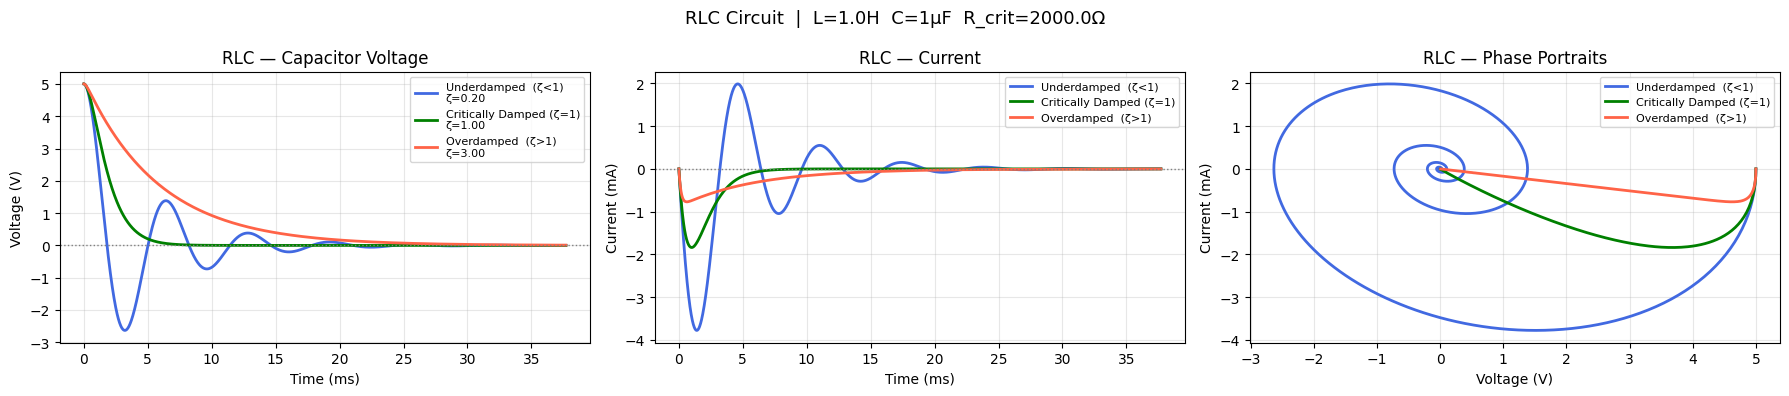

Critical resistance: R_crit = 2000.00 Ω
  Underdamped  (ζ<1): R=400.0Ω  ζ=0.200
  Critically Damped (ζ=1): R=2000.0Ω  ζ=1.000
  Overdamped  (ζ>1): R=6000.0Ω  ζ=3.000


In [6]:
# ── RLC Circuit ───────────────────────────────────────────────────────────────

# Fixed parameters
L_rlc = 1.0      # Inductance (H)
C_rlc = 1e-6     # Capacitance (F)
Vc0_rlc = 5.0    # Initial voltage (V)
omega0_rlc = 1 / np.sqrt(L_rlc * C_rlc)

# Three damping cases
R_critical = 2 * np.sqrt(L_rlc / C_rlc)   # Critical resistance
cases = {
    'Underdamped  (ζ<1)':  R_critical * 0.2,
    'Critically Damped (ζ=1)': R_critical,
    'Overdamped  (ζ>1)':   R_critical * 3.0,
}

T_rlc = 2 * np.pi / omega0_rlc
t_span_rlc = (0, 6 * T_rlc)
t_eval_rlc = np.linspace(*t_span_rlc, 2000)

def rlc_ode(t, y, R):
    Vc, I = y
    dVc_dt = I / C_rlc
    dI_dt  = -Vc / L_rlc - (R / L_rlc) * I
    return [dVc_dt, dI_dt]

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = ['royalblue', 'green', 'tomato']
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

for (label, R), color in zip(cases.items(), colors):
    zeta = (R / 2) * np.sqrt(C_rlc / L_rlc)
    sol = solve_ivp(rlc_ode, t_span_rlc, y0=[Vc0_rlc, 0.0],
                    t_eval=t_eval_rlc, method='RK45', args=(R,))
    Vc = sol.y[0]
    I  = sol.y[1]

    ax1.plot(t_eval_rlc * 1e3, Vc, label=f'{label}\nζ={zeta:.2f}', color=color)
    ax2.plot(t_eval_rlc * 1e3, I * 1e3, label=f'{label}', color=color)
    ax3.plot(Vc, I * 1e3, color=color, label=f'{label}')

ax1.axhline(0, color='gray', linestyle=':', linewidth=1)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('RLC — Capacitor Voltage')
ax1.legend(fontsize=8)

ax2.axhline(0, color='gray', linestyle=':', linewidth=1)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Current (mA)')
ax2.set_title('RLC — Current')
ax2.legend(fontsize=8)

ax3.set_xlabel('Voltage (V)')
ax3.set_ylabel('Current (mA)')
ax3.set_title('RLC — Phase Portraits')
ax3.legend(fontsize=8)

plt.suptitle(f'RLC Circuit  |  L={L_rlc:.1f}H  C={C_rlc*1e6:.0f}µF  R_crit={R_critical:.1f}Ω', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Critical resistance: R_crit = {R_critical:.2f} Ω")
for label, R in cases.items():
    zeta = (R / 2) * np.sqrt(C_rlc / L_rlc)
    print(f"  {label}: R={R:.1f}Ω  ζ={zeta:.3f}")